In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as integrate
import cmath
from math import factorial

# **Exercise 1**

## **1a**

In [2]:
def trap_int(a,b,N,func):
    i =0 
    h = (b-a)/N
    Area = 0
    while i < N:
        Area+= 1/2 * (func(a+h*i) + func(a+h*(i+1))) * h
        i+=1
    return Area

def polyQ1(x): 
    return x**4 -2*x +1

result1a = trap_int(0,2,10,polyQ1)
error1a = (result1a-4.4)/4.4

print(f"The trapezoidal integration gives {result1a} with a fractional error of {error1a}")

The trapezoidal integration gives 4.50656 with a fractional error of 0.024218181818181812


## **1b**

In [3]:
def simp_int(a,b,N,f):
    i = 0 
    h = (b-a)/N
    Area = 0
    while i < N :
        Area += h/6 * (f(a+h*i)+f(a+h*(i+1))+ 4*f(a+h*(i+1/2)))
        i += 1
    return Area

result1b = simp_int(0,2,10,polyQ1)
error1b = (result1b-4.4)/4.4

print(f"The simpson integration gives {result1b} with a fractional error of {error1b}")



The simpson integration gives 4.400026666666667 with a fractional error of 6.060606060645765e-06


## **1c**

For 10 slices trapezoidal integration gives 4.50656 with error 0.024218181818181812
For 10 slices Simpson integration gives 4.400026666666667 with error 6.060606060645765e-06
For 100 slices trapezoidal integration gives 4.401066656000001 with error 0.0002424218181819946
For 100 slices Simpson integration gives 4.400000002666666 with error 6.060604543475537e-10
For 1000 slices trapezoidal integration gives 4.400010666665602 with error 2.424242182148943e-06
For 1000 slices Simpson integration gives 4.400000000000267 with error 6.055761952500853e-14


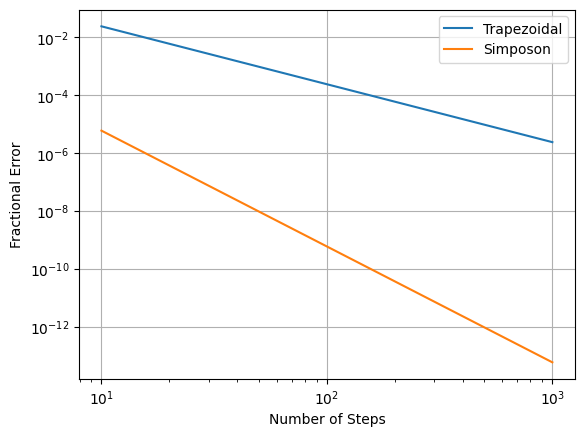

In [4]:
def trapQ1(N) :
    return trap_int(0,2,N,polyQ1)

def simpQ1(N):
    return simp_int(0,2,N,polyQ1)

def errorQ1(x):
    return np.abs((x-4.4)/4.4)

N = [10,100,1000]

trap = [trapQ1(x) for x in N]
simp = [simpQ1(x) for x in N]
errtrap = [errorQ1(x) for x in trap]
errsimp = [errorQ1(x) for x in simp]

for i in range(0,len(N)):
    print(f'For {N[i]} slices trapezoidal integration gives {trap[i]} with error {errtrap[i]}')
    print(f'For {N[i]} slices Simpson integration gives {simp[i]} with error {errsimp[i]}')


plt.figure()
plt.plot(N,errtrap, label = 'Trapezoidal')
plt.plot(N,errsimp, label = 'Simposon')
plt.legend()
plt.xlabel('Number of Steps')
plt.ylabel('Fractional Error')
plt.yscale('log')
plt.grid()
plt.xscale('log')
plt.show()

For the same number of slice, Simpson's rule is much more accurate than Trapezoidal rule

## **1d**

$$ I = I_1 + c h_1^2$$
$$ I = I_2 + c \left(\frac{h_1}{2}\right)^2$$
$$\implies  \text{error} = c \left(\frac{h_1}{2}\right)^2 = \frac{I_2 - I_1}{3}


In [5]:
trap20 = trap_int(0,2,20,polyQ1)
trap10= trap_int(0,2,10,polyQ1)
err1d = np.abs((trap20-trap10)/3)
err20 = errorQ1(trap20)
print(f'Error calculated using this method is {err1d} whereas that found by taking the exact difference is {err20}' )

Error calculated using this method is 0.026633333333332843 whereas that found by taking the exact difference is 0.00605909090909124


The error calculated from this method is more than the actual error as is expected.  
This is because we terminated the expansion at power 2 but there are terms of all even powers

# **Exercise 2**

## **2a**

In the code, we will take advantage of the already computed integrals and not repeat there calculation as was discussed in class.  
A brief derivation is shown below.

Let us compute the nth integral $I_k$ of the function f(x) from a to b, with n slices where $ n = 2^k$  
Define $ h_k = \frac{b-a}{n} $,   $x_i = a + i h_k$

$$
\begin{aligned}
I_k = \sum_{i=0}^{n-1} \frac{h_k}{2}\,\bigl(f(x_i) + f(x_{i+1})\bigr)
\end{aligned}
$$

Now,  $ h_{k+1} = \frac{b-a}{2n} = \frac{h_k}{2} $,  $y_i = a + i h_{k+1}$,  
Note that, $x_i = y_{2i}$. 

$$
\begin{aligned}
I_{k+1} &= \sum_{i=0}^{2n-1} \frac{h_{k+1}}{2}\bigl(f(y_i) + f(y_{i+1})\bigr) \\[6pt]
&= \sum_{i=0}^{n-1} \frac{h_{k+1}}{2}
\bigl((f(y_{2i}) + f(y_{2i+1})) + (f(y_{2i+1}) + f(y_{2i+2}))\bigr) \\[6pt]
&= \sum_{i=0}^{n-1} \frac{h_k}{4}
\bigl(f(y_{2i}) + 2f(y_{2i+1}) + f(y_{2i+2})\bigr) \\[6pt]
&= \sum_{i=0}^{n-1} \frac{h_k}{4}\bigl(f(y_{2i}) + f(y_{2i+2})\bigr)
 + \sum_{i=0}^{n-1} \frac{h_k}{2} f(y_{2i+1}) \\[6pt]
&= \frac{I_k}{2} + \sum_{i=0}^{n-1} \frac{h_k}{2}
 f\!\left(a + \left(i+\tfrac12\right) h_k\right).


\end{aligned}
$$








In [6]:
def f2(x):
    return (np.sin(np.sqrt(100*x)))**2

eps = 1e-6
a = 0
b = 1
n = 1/2
sum_new = (1/2)*(b-a)*(f2(a)+f2(b))

print(f'Slices\tSum\t\tError')
print(f'1\t{sum_new:.10f}\t-')

error = 1
while error > eps:
    n = 2*n
    n = int(n)
    s = 0
    sum_old = sum_new
    h = (b-a)/n
    for i in range(n):
        s += f2(a+(i+1/2)*h)
    sum_new = (1/2)*(sum_new + h *s)
    error =  np.abs(sum_new-sum_old)/3
    print(f'{2*n}\t{sum_new:.10f}\t{error:.2e}')




Slices	Sum		Error
1	0.1479794845	-
2	0.3252319078	5.91e-02
4	0.5122828507	6.24e-02
8	0.4029974485	3.64e-02
16	0.4301033693	9.04e-03
32	0.4484146658	6.10e-03
64	0.4539129312	1.83e-03
128	0.4553485044	4.79e-04
256	0.4557112665	1.21e-04
512	0.4558021997	3.03e-05
1024	0.4558249481	7.58e-06
2048	0.4558306362	1.90e-06
4096	0.4558320583	4.74e-07


## **2b**

$$R_{k,m} =  R_{k,m-1} + \frac{R_{k,m-1}- R_{k-1,m-1}}{2^{2m}-1}

In [7]:
def f2(x):
    return (np.sin(np.sqrt(100*x)))**2


eps = 1e-6
a = 0
b = 1
n = 1/2
k = 0
sum_new = (1/2)*(b-a)*(f2(a)+f2(b))

Rom_table = []
Rom_table.append([sum_new])

print(f'Level\tSlices\tRomberg(k,k)\tError')
print(f'{k}\t1\t{Rom_table[0][0]:.10f}\t-')

error = 1
while error > eps:
    n = 2*n
    n = int(n)
    s = 0
    sum_old = sum_new
    h = (b-a)/n

    for i in range(n):
        s += f2(a+(i+1/2)*h)

    sum_new = (1/2)*(sum_new + h*s)

    k += 1

    Rom_table.append(np.zeros(k+1))
    Rom_table[k][0] = sum_new
    for j in range(1, k+1):
        Rom_table[k][j] = Rom_table[k][j-1] + (Rom_table[k][j-1] - Rom_table[k-1][j-1])/(4**j - 1)
    error = np.abs(Rom_table[k][k] - Rom_table[k-1][k-1])/(2**k -1)

    print(f'{k}\t{2*n}\t{Rom_table[k][k]:.10f}\t{error:.2e}')


print("\nRomberg Table:")
for row in Rom_table:
    print(row)

Level	Slices	Romberg(k,k)	Error
0	1	0.1479794845	-
1	2	0.3843160489	2.36e-01
2	4	0.5873209728	6.77e-02
3	8	0.3489738619	3.40e-02
4	16	0.4458037647	6.46e-03
5	32	0.4557774922	3.22e-04
6	64	0.4558324945	8.73e-07

Romberg Table:
[np.float64(0.147979484546652)]
[0.32523191 0.38431605]
[0.51228285 0.57463317 0.58732097]
[0.40299745 0.36656898 0.35269804 0.34897386]
[0.43010337 0.43913868 0.44397666 0.44542552 0.44580376]
[0.44841467 0.45451843 0.45554375 0.45572735 0.45576775 0.45577749]
[0.45391293 0.45574569 0.4558275  0.45583201 0.45583242 0.45583248
 0.45583249]


## **2c**

$$
n = 2^k, \qquad h_k = \frac{b-a}{n}, \qquad x_i = a + i h_k.
$$


$$
\begin{aligned}
S_k
&= \frac{h_k}{3}
\left[
f(x_0)
+4\sum_{i=1}^{n/2} f(x_{2i-1})
+2\sum_{i=1}^{n/2-1} f(x_{2i})
+f(x_n)
\right].
\end{aligned}
$$

Refinement:

$$
h_{k+1} = \frac{h_k}{2}, 
\qquad y_i = a + i h_{k+1},
\qquad x_i = y_{2i}.
$$

New points (midpoints):

$$
y_{2i-1} = a + \left(i-\tfrac12\right) h_k.
$$

$$
\begin{aligned}
S_{k+1}
&= \frac{h_{k+1}}{3}
\left[
f(y_0)
+4\sum_{i=1}^{n} f(y_{2i-1})
+2\sum_{i=1}^{n-1} f(y_{2i})
+f(y_{2n})
\right].
\end{aligned}
$$


$$
\begin{aligned}
S_{k+1}
&= \frac{h_k}{6}
\left[
f(x_0)
+4\sum_{i=1}^{n} f\!\left(a+\left(i-\tfrac12\right)h_k\right)
+2\sum_{i=1}^{n-1} f(x_i)
+f(x_n)
\right].
\end{aligned}
$$


$$
\begin{aligned}
S_{k+1}
=
\frac{h_k}{6}
\Bigg[
f(x_0)+f(x_n)
+2\sum_{i=1}^{n-1} f(x_i)
+4\sum_{i=1}^{n} f\!\left(a+\left(i-\tfrac12\right)h_k\right)
\Bigg].
\end{aligned}
$$


Error estimate:

$$
\text{error} \approx \frac{|S_{k+1}-S_k|}{15}.
$$


In [8]:
eps = 1e-6
a = 0
b = 1
n = 2

h = (b-a)/n
fa = f2(a)
fb = f2(b)
fmid = f2(a + h)

sum_odd = fmid       # x1
sum_even = 0
S_new = (h/3)*(fa + 4*sum_odd + fb)

print("Slices\tSimpson\t\tError")
print(f"{n}\t{S_new:.10f}\t-")

error = 1
while error > eps:
    S_old = S_new
    n = 2*n
    h = (b-a)/n
    sum_even += sum_odd  # previous odd points become even
    sum_odd = 0
    for i in range(1, n, 2):
        sum_odd += f2(a + i*h)
    S_new = (h/3)*(fa + 4*sum_odd + 2*sum_even + fb)

    error = abs(S_new - S_old)/15

    print(f"{n}\t{S_new:.10f}\t{error:.2e}")


Slices	Simpson		Error
2	0.3843160489	-
4	0.5746331650	1.27e-02
8	0.3665689811	1.39e-02
16	0.4391386762	4.84e-03
32	0.4545184313	1.03e-03
64	0.4557456864	8.18e-05
128	0.4558270288	5.42e-06
256	0.4558321871	3.44e-07


# **Problem 3**

## **3a**

$$
E = \frac{1}{2} m \left(\frac{dx}{dt}\right)^2 + V(x)
$$

$$
E = V(a)
$$

$$
\frac{1}{2} m \left(\frac{dx}{dt}\right)^2 = V(a) - V(x)
$$

$$
\frac{dx}{dt} = -\sqrt{\frac{2}{m}\bigl(V(a)-V(x)\bigr)}
$$

$$
dt = -\sqrt{\frac{m}{2}} \,\frac{dx}{\sqrt{V(a)-V(x)}}
$$

$$
\frac{T}{4} = \sqrt{\frac{m}{2}} \int_{0}^{a} \frac{dx}{\sqrt{V(a)-V(x)}}
$$

$$
T = 4\sqrt{\frac{m}{2}} \int_{0}^{a} \frac{dx}{\sqrt{V(a)-V(x)}}
$$



## **3b**

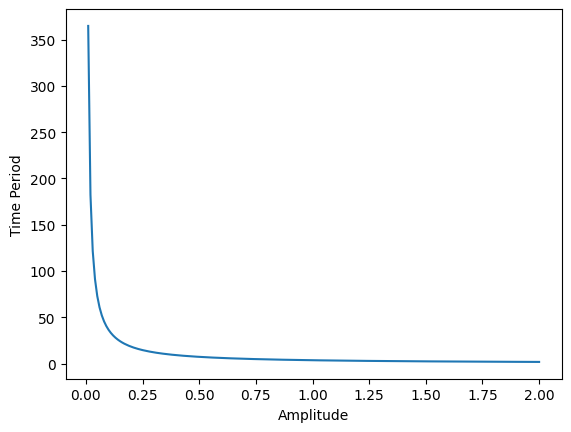

In [9]:
from numpy.polynomial.legendre import leggauss

def V(x):
    return x**4

def f(x,a):
    return 1/np.sqrt(V(a)-V(x))

def period(a):
    n = 20
    nodes, weights = leggauss(n)
    total = 0
    for t, w in zip(nodes, weights):
        x = (a/2)*(t + 1)     # map from [-1,1] -> [0,a]
        total += w * (a/2) * f(x, a)   # Jacobian included here
    return 4/np.sqrt(2) * total

a_vals = np.arange(0.01,2.01,0.01)
period_vals = np.array([period(a) for a in a_vals])

plt.figure()
plt.plot(a_vals,period_vals)
plt.xlabel('Amplitude')
plt.ylabel('Time Period')
plt.show()

## **3c**

As amplitude increases, energy scales as $a^4$, so the particle’s velocity grows faster than the distance travelled, leading to a shorter period. Near $x=0$, the potential is very flat since $V''(0)=0$, so the restoring force is weak for small amplitudes. The motion therefore slows down significantly near equilibrium. Hence $T \propto 1/a$, and the period diverges as $a \to 0$.



# **Problem 4**

## **4a**

Take a differential mass dm at coordinates (x,y) on the sheet.
$$dm = \sigma \, dx \, dy$$

The potential energy due to dm on the 1kg mass kept at the point (0,0,z) is then,
$$dU = -\frac{G\sigma \, dx \, dy}{\sqrt{x^2 + y^2 + z^2}}$$

Integration to get the total potential
$$U = -G\sigma\int_{-L/2}^{L/2}\int_{-L/2}^{L/2} \frac{dx \, dy}{\sqrt{x^2 + y^2 + z^2}}$$

Now, using 
$$F_z = -\frac{\partial U}{\partial z}$$
and
$$\frac{\partial}{\partial z}\left(\frac{1}{\sqrt{x^2 + y^2 + z^2}}\right) = -\frac{z}{(x^2 + y^2 + z^2)^{3/2}}$$
We get,
$$F_z = G\sigma z \int_{-L/2}^{L/2}\int_{-L/2}^{L/2} \frac{dx \, dy}{(x^2 + y^2 + z^2)^{3/2}}$$
as required.

## **4b**

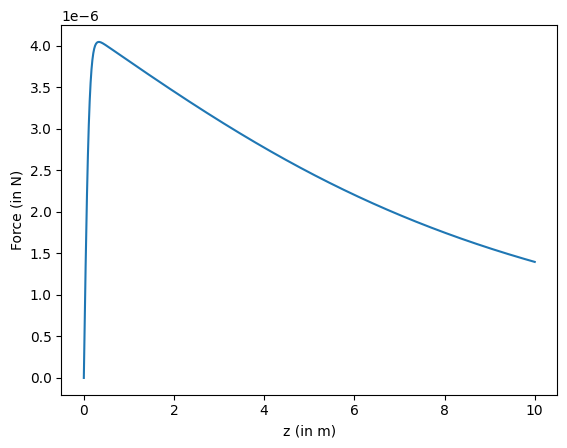

In [10]:
def fgrav(x,y,z):
    return (1/np.sqrt(x*x+y*y+z*z))**3

def integral(z,L):
    n = 100
    nodes, weights = leggauss(n)
    total = 0
    for x,w_x in zip(nodes,weights):
        for y,w_y in zip(nodes,weights):
            total += w_x * w_y * fgrav(x*L,y*L,z) * L
    return total



def force_Z(z):
    g = 6.674 * 1e-11
    l = 10
    sigma = 1e5
    return g*sigma*z*integral(z,l)

z_vals = np.linspace(0,10,1000)
force_vals = np.array([force_Z(z) for z in z_vals])
plt.figure()
plt.plot(z_vals,force_vals)
plt.xlabel('z (in m)')
plt.ylabel('Force (in N)')
plt.show()

## **4c**

As z tends to 0 the intergrand becomes highly peaked around origin. So major part of the integral comes from a small disc around origin i.e the integral becomes localized. But as Gaussian Quadrature uses fixed sampling points, most of the quadrature nodes do not land up close to origin and the integrand is evaluated at points where it is is tiny.
To resolve this, we can use adaptive gaussian quadrature method which will note this high derivative near origin and would thus increase the number of samping points near the origin.

# **Problem 5**

## **5a**
Let d be the slit separation, then - 
$$q(u) = q(u+d)$$
$$\sin^2(\alpha u) = \sin^2(\alpha (u+d))$$
Period of $\sin^2(x)$ is $\pi$   
So, $$ \alpha u + \pi = \alpha u + \alpha d$$
$$ d = \frac{\pi}{\alpha}$$

## **5b**

In [11]:
d = 20 * 1e-6
alpha = np.pi/d
def q(u):
    return np.sin(alpha*u) **2

## **5c**

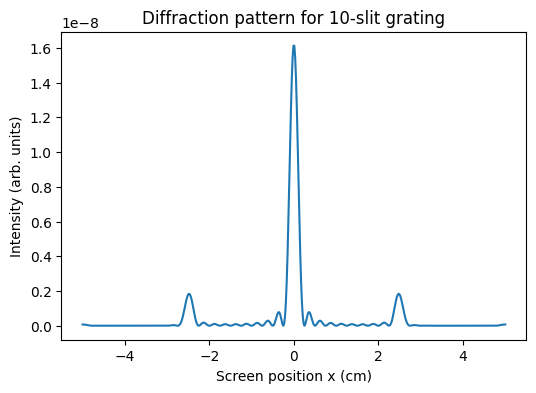

In [12]:
import cmath

lam = 500e-9   
f = 1.0           
Nslits = 10      
w = Nslits * d


def A(u):
    return np.sqrt(np.abs(q(u)))


Nu = 10000          
u = np.linspace(-w/2, w/2, Nu)
du = u[1] - u[0]
Au = A(u)
x = np.linspace(-0.05, 0.05, 500)   
k = 2*np.pi/(lam*f)

I = np.zeros_like(x)

for i, xi in enumerate(x):

    integrand = []

    for uj, Auj in zip(u, Au):
        phase = cmath.exp(1j * k * xi * uj)
        integrand.append(Auj * phase)

    integral = np.trapezoid(integrand, u)

    I[i] = abs(integral)**2


plt.figure(figsize=(6,4))
plt.plot(x*100, I)  
plt.xlabel("Screen position x (cm)")
plt.ylabel("Intensity (arb. units)")
plt.title("Diffraction pattern for 10-slit grating")
plt.show()



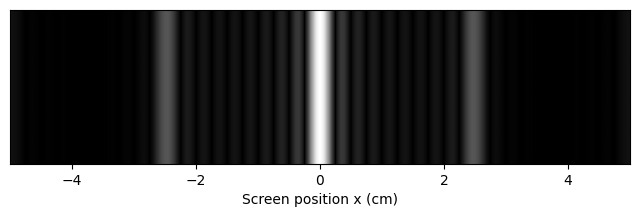

In [13]:
I_norm = I / np.max(I)

# nonlinear scaling (important!)
display_intensity = np.sqrt(I_norm)

height = 100
img = np.tile(display_intensity, (height,1))

plt.figure(figsize=(8,2))

plt.imshow(
    img,
    extent=[x[0]*100, x[-1]*100, 0, 1],
    aspect='auto',
    cmap='gray'
)

plt.xlabel("Screen position x (cm)")
plt.yticks([])

plt.show()


## **5e**

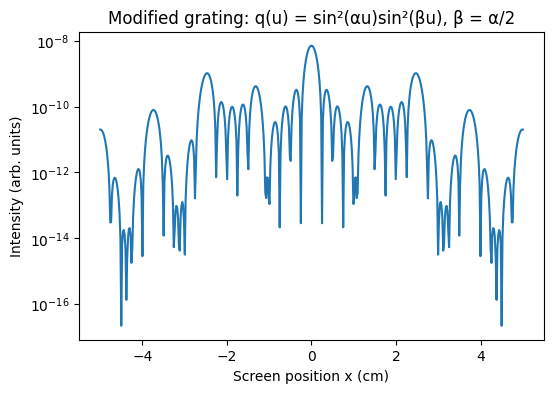

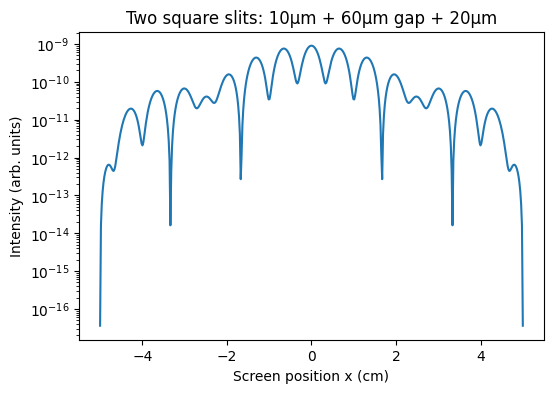

In [14]:
# Exercise 5e-i

beta = alpha / 2

def q_ei(u):
    return np.sin(alpha*u)**2 * np.sin(beta*u)**2

A_ei = np.sqrt(np.abs(q_ei(u)))

I_ei = np.zeros_like(x)

for i, xi in enumerate(x):
    integrand = []
    for uj, Auj in zip(u, A_ei):
        phase = cmath.exp(1j * k * xi * uj)
        integrand.append(Auj * phase)
    integral = np.trapezoid(integrand, u)
    I_ei[i] = abs(integral)**2

plt.figure(figsize=(6,4))
plt.plot(x*100, I_ei)
plt.xlabel("Screen position x (cm)")
plt.ylabel("Intensity (arb. units)")
plt.title("Modified grating: q(u) = sin²(αu)sin²(βu), β = α/2")
plt.yscale('log')
plt.show()


# Exercise 5e-ii

slit1_width = 10e-6
slit2_width = 20e-6
gap = 60e-6

slit1_center = -(gap + slit2_width) / 2
slit2_center = (gap + slit1_width) / 2

def q_eii(u):
    if (slit1_center - slit1_width/2 <= u <= slit1_center + slit1_width/2) or \
       (slit2_center - slit2_width/2 <= u <= slit2_center + slit2_width/2):
        return 1.0
    return 0.0

q_eii_vec = np.vectorize(q_eii)

total_width = slit1_width + gap + slit2_width + 40e-6
u_eii = np.linspace(-total_width/2, total_width/2, Nu)
A_eii = np.sqrt(np.abs(q_eii_vec(u_eii)))

I_eii = np.zeros_like(x)

for i, xi in enumerate(x):
    integrand = []
    for uj, Auj in zip(u_eii, A_eii):
        phase = cmath.exp(1j * k * xi * uj)
        integrand.append(Auj * phase)
    integral = np.trapezoid(integrand, u_eii)
    I_eii[i] = abs(integral)**2

plt.figure(figsize=(6,4))
plt.plot(x*100, I_eii)
plt.xlabel("Screen position x (cm)")
plt.ylabel("Intensity (arb. units)")
plt.title("Two square slits: 10µm + 60µm gap + 20µm")
plt.yscale('log')
plt.show()

# **Exercise 6: Differentiating by Integrating**

In [15]:
def calculate_derivatives_cauchy(n_derivatives=20, N=10000):
    derivatives = []
    exact_values = []
    for m in range(n_derivatives):
        sum_val = 0.0j
        for k in range(N):
            z_k = cmath.exp(1j * 2 * np.pi * k / N)
            f_z_k = cmath.exp(2 * z_k)
            sum_val += f_z_k * cmath.exp(-1j * 2 * np.pi * k * m / N)
        derivative = (factorial(m) / N) * sum_val
        derivatives.append(derivative.real)
        exact_values.append(2**m)
    return np.array(derivatives), np.array(exact_values)

derivatives, exact_values = calculate_derivatives_cauchy(n_derivatives=20, N=10000)

print(derivatives)

[1.00000000e+00 2.00000000e+00 4.00000000e+00 8.00000000e+00
 1.60000000e+01 3.20000000e+01 6.40000000e+01 1.28000000e+02
 2.56000000e+02 5.12000000e+02 1.02400000e+03 2.04800000e+03
 4.09600000e+03 8.19200000e+03 1.63840000e+04 3.27679995e+04
 6.55359956e+04 1.31071930e+05 2.62142903e+05 5.24269153e+05]


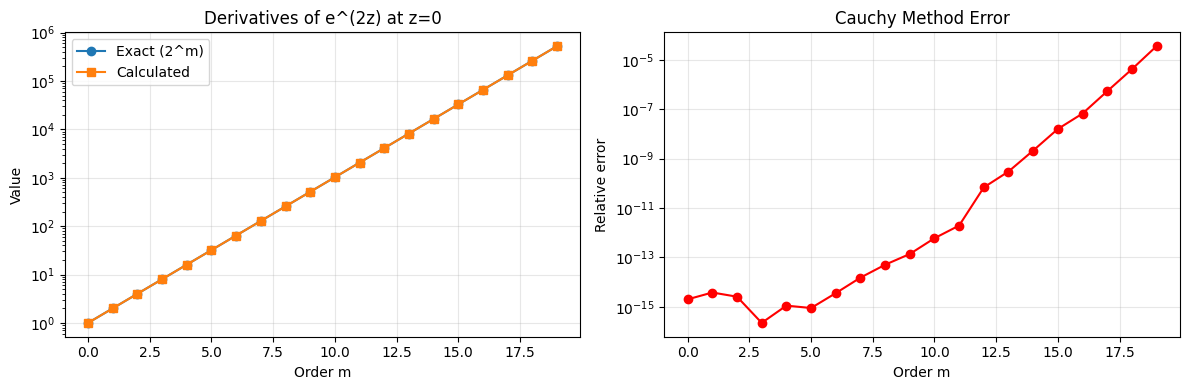

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
m_vals = np.arange(len(derivatives))
ax1.semilogy(m_vals, exact_values, 'o-', label='Exact (2^m)')
ax1.semilogy(m_vals, np.abs(derivatives), 's-', label='Calculated')
ax1.set_xlabel('Order m')
ax1.set_ylabel('Value')
ax1.set_title('Derivatives of e^(2z) at z=0')
ax1.legend()
ax1.grid(True, alpha=0.3)

errors = np.abs(derivatives - exact_values) / exact_values
ax2.semilogy(m_vals, errors, 'ro-')
ax2.set_xlabel('Order m')
ax2.set_ylabel('Relative error')
ax2.set_title('Cauchy Method Error')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# **Exercise 7: Image Processing and STM**

In [32]:
# Exercise 7a: Load altitude data and calculate derivatives

import pandas as pd

altitude = pd.read_csv('altitude.txt', header=None, delim_whitespace=True).values

print(f"Altitude data shape: {altitude.shape}")

h = 30000

def deriv(w, h):
    ny, nx = w.shape
    dw_dx = np.zeros_like(w, dtype=float)
    dw_dy = np.zeros_like(w, dtype=float)
    
    dw_dx[1:-1, 1:-1] = (w[1:-1, 2:] - w[1:-1, :-2]) / (2 * h)
    dw_dy[1:-1, 1:-1] = (w[2:, 1:-1] - w[:-2, 1:-1]) / (2 * h)
    
    dw_dx[1:-1, 0] = (w[1:-1, 1] - w[1:-1, 0]) / h
    dw_dx[1:-1, -1] = (w[1:-1, -1] - w[1:-1, -2]) / h
    dw_dy[0, 1:-1] = (w[1, 1:-1] - w[0, 1:-1]) / h
    dw_dy[-1, 1:-1] = (w[-1, 1:-1] - w[-2, 1:-1]) / h
    
    dw_dx[0, 0] = (w[0, 1] - w[0, 0]) / h
    dw_dx[0, -1] = (w[0, -1] - w[0, -2]) / h
    dw_dx[-1, 0] = (w[-1, 1] - w[-1, 0]) / h
    dw_dx[-1, -1] = (w[-1, -1] - w[-1, -2]) / h
    
    dw_dy[0, 0] = (w[1, 0] - w[0, 0]) / h
    dw_dy[0, -1] = (w[1, -1] - w[0, -1]) / h
    dw_dy[-1, 0] = (w[-1, 0] - w[-2, 0]) / h
    dw_dy[-1, -1] = (w[-1, -1] - w[-2, -1]) / h
    
    return dw_dx, dw_dy

dw_dx_alt, dw_dy_alt = deriv(altitude, h)

print(f"∂w/∂x range: {dw_dx_alt.min():.8f} to {dw_dx_alt.max():.8f}")
print(f"∂w/∂y range: {dw_dy_alt.min():.8f} to {dw_dy_alt.max():.8f}")

Altitude data shape: (512, 1024)
∂w/∂x range: -0.13228207 to 0.11335850
∂w/∂y range: -0.11307887 to 0.11159968


/var/folders/7x/9qqcy_qn5rzfmrdz0vr6hq_40000gp/T/ipykernel_92949/2895080821.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  altitude = pd.read_csv('altitude.txt', header=None, delim_whitespace=True).values


We used finite difference method to calculate derivatives

**Interior points:** Central difference formula
- ∂w/∂x ≈ [w(x+h) - w(x-h)] / (2h)
- Second order accurate O(h²)

**Edge points:** Forward/backward difference
- Forward: ∂w/∂x ≈ [w(x+h) - w(x)] / h
- Backward: ∂w/∂x ≈ [w(x) - w(x-h)] / h
- First order accurate O(h)

**Why two methods?** Central difference requires neighbors on both sides. At edges, we only have data on one side, so we use forward/backward differences instead. Interior points use central difference for better accuracy.

**Grid spacing:** h = 30,000 meters between grid points

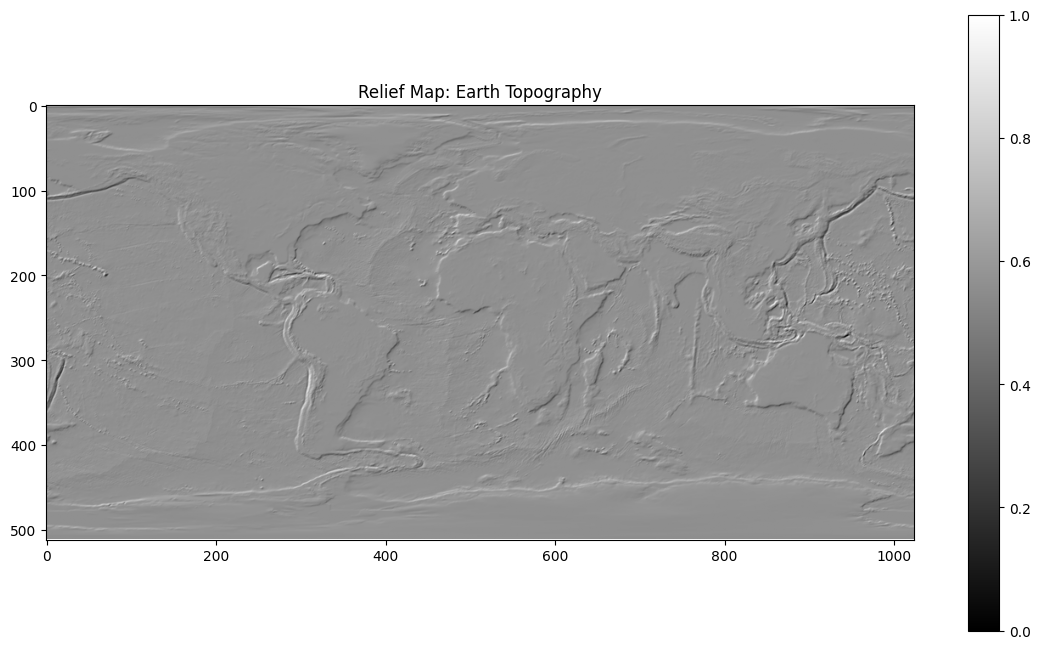

In [35]:
phi = np.radians(45)

dw_dx_norm = dw_dx_alt / np.sqrt(dw_dx_alt**2 + dw_dy_alt**2 + 1)
dw_dy_norm = dw_dy_alt / np.sqrt(dw_dx_alt**2 + dw_dy_alt**2 + 1)
dw_dz_norm = 1 / np.sqrt(dw_dx_alt**2 + dw_dy_alt**2 + 1)

light_x = np.cos(phi)
light_y = np.sin(phi)
light_z = 0

I_alt = light_x * dw_dx_norm + light_y * dw_dy_norm + light_z * dw_dz_norm
I_alt_norm = (I_alt - I_alt.min()) / (I_alt.max() - I_alt.min())

plt.figure(figsize=(14,8))
plt.imshow(I_alt_norm, cmap='gray', origin='upper')
plt.title('Relief Map: Earth Topography')
plt.colorbar()
plt.show()

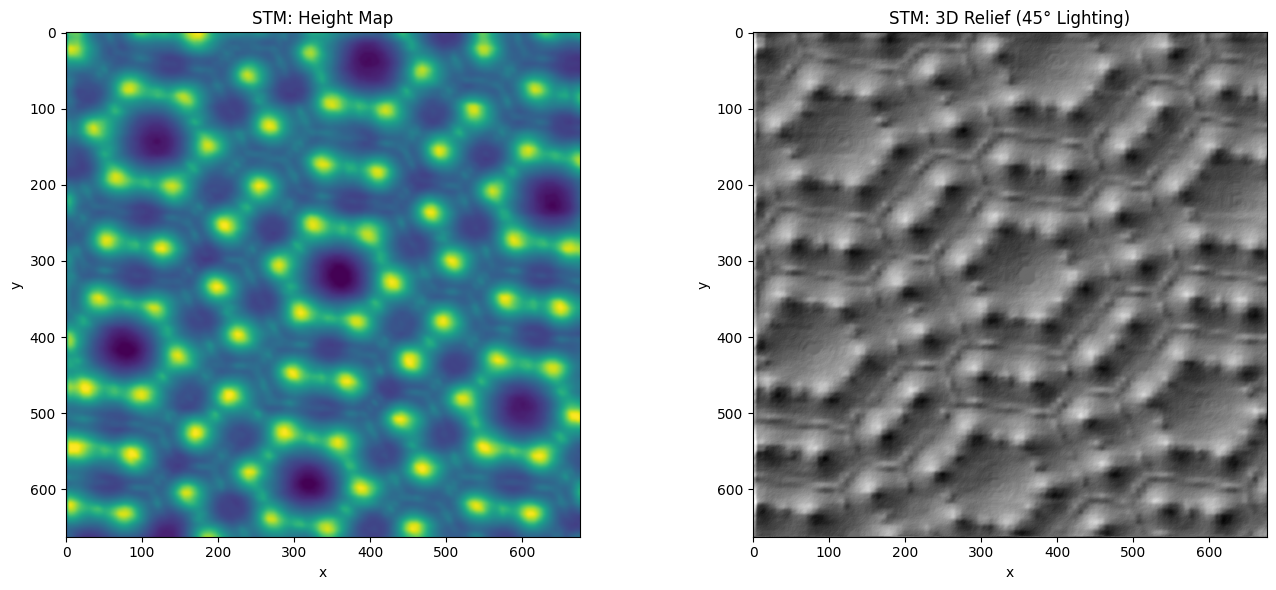

In [ ]:
# Exercise 7c: STM visualization

stm_data = pd.read_csv('stm.txt', header=None, sep=' ').values

dw_dx_stm, dw_dy_stm = deriv(stm_data, 2.5)

dw_dx_norm_stm = dw_dx_stm / np.sqrt(dw_dx_stm**2 + dw_dy_stm**2 + 1)
dw_dy_norm_stm = dw_dy_stm / np.sqrt(dw_dx_stm**2 + dw_dy_stm**2 + 1)
dw_dz_norm_stm = 1 / np.sqrt(dw_dx_stm**2 + dw_dy_stm**2 + 1)

light_x = np.cos(phi)
light_y = np.sin(phi)
light_z = 0

I_stm = light_x * dw_dx_norm_stm + light_y * dw_dy_norm_stm + light_z * dw_dz_norm_stm
I_stm_norm = (I_stm - I_stm.min()) / (I_stm.max() - I_stm.min())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(stm_data, cmap='viridis', origin='upper')
axes[0].set_title('STM: Height Map')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')

axes[1].imshow(I_stm_norm, cmap='gray', origin='upper')
axes[1].set_title('STM: 3D Relief (45° Lighting)')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')

plt.tight_layout()
plt.show()